# Coastal Water Quality: Phase 1 Scene Overview

> Terms, units, and acronyms are defined in [`GLOSSARY.md`](./GLOSSARY.md).
> This notebook opens the sequence by locating the scene, water, and sediment plume.

**Scene:** `20250302_030003_92_4001`, Kutai Timur, East Kalimantan, **Borneo, Indonesia**, on the **Makassar Strait** coast. The Sangatta River enters the sea here.

**Sensor:** Tanager-1 is a hyperspectral imaging spectrometer. It records **426 contiguous bands** from about **380 to 2500 nm** at about **5 nm** spacing. Each pixel has a reflectance spectrum, rather than only three broad colour values.

**Goal:** The RGB image shows a turbid sediment plume leaving the river mouth. This is a **Case-2** coastal-water scene. Later phases examine turbidity or suspended sediment, chlorophyll-*a*, and CDOM in the hyperspectral cube.

> **Case-1 and Case-2 water.** Case-1 open-ocean optics are mainly driven by phytoplankton. Case-2 coastal or estuarine optics vary independently with phytoplankton (chlorophyll-*a*), suspended sediment (TSM), and coloured dissolved organic matter (CDOM). Their signals overlap, so this river-fed scene is more difficult to interpret.

**Scene facts**

| Property | Value | Meaning / unit |
|---|---|---|
| Acquired | 2025-03-02 03:00 UTC | overpass time |
| Cloud / haze | 2% / 1% | fraction of scene flagged, very clean |
| Sun elevation | 68.3° | high sun, good illumination and low shadow |
| Off-nadir | 9.2° | near-vertical view, low geometric distortion |
| GSD | 33 m | Ground Sample Distance, pixel size on the ground |
| Collection | `coastal-water-bodies` | Tanager coastal water-bodies catalogue |

**This notebook**
1. Reads scene metadata from the Tanager inventory.
2. Shows the thumbnail and RGB ortho image.
3. Inspects the `beta_udm` quality mask and counts excluded pixels.
4. Places the footprint on an interactive map.
5. Leaves the Phase 2 spectral check for when the HDF5 cube is available.
6. Summarises the scene for Phase 2.


## 0. Imports and paths

The notebook finds the project root by locating `data/inventory`. It then resolves the scene data and figure folders, so it works from any Jupyter launch directory.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from PIL import Image

def find_root(start=Path.cwd()):
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "inventory").exists():
            return cand
    return p

PROJECT_ROOT = find_root()
SCENE_ID = "20250302_030003_92_4001"

DATA_DIR = PROJECT_ROOT / "data" / "coastal" / SCENE_ID
FIG_DIR  = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Scene data   :", DATA_DIR)
print("Figures      :", FIG_DIR)
print("Assets found :", sorted(p.name for p in DATA_DIR.glob("*")) if DATA_DIR.exists() else "NONE - run scripts/download_coastal.py")


Project root : C:\Users\Dheemant\Documents\Tanager-Open-Competition
Scene data   : C:\Users\Dheemant\Documents\Tanager-Open-Competition\data\Coastal\coastal\20250302_030003_92_4001
Figures      : C:\Users\Dheemant\Documents\Tanager-Open-Competition\data\Coastal\figures
Assets found : ['geolocation_array.tif', 'ortho_beta_udm.tif', 'ortho_radiance_hdf5.h5', 'ortho_sr_hdf5.h5', 'ortho_visual.tif', 'thumbnail.png']


## 1. Scene metadata

The STAC inventory at `data/inventory/tanager_inventory.csv` has one row per `(collection, scene)`. This scene is listed in two collections, so two near-identical rows are expected. The fields below describe the scene location and whether it is suitable for water analysis.

| Field | Unit / type | Why it matters for water quality |
|---|---|---|
| `datetime` | ISO-8601 UTC | tide and sun state at capture |
| `cloud_percent`, `light_haze_percent` | % of scene | clouds and haze contaminate water-leaving signal |
| `quality_category` | category | overall usability flag |
| `sun_elevation`, `sun_azimuth` | degrees | illumination geometry and sun-glint risk |
| `off_nadir` | degrees | view geometry, glint, and distortion |
| `gsd` | metres | smallest resolvable plume feature |
| `centroid_lat/lon`, `bbox` | degrees | location and footprint: west, south, east, north |


In [2]:
inv = pd.read_csv(PROJECT_ROOT / "data" / "inventory" / "tanager_inventory.csv")
rows = inv[inv["item_id"] == SCENE_ID]

print(f"Rows for this scene: {len(rows)}  (collections: {rows['collection'].tolist()})")
print()
r = rows.iloc[0]
summary = {
    "datetime":             r["datetime"],
    "location":             r["location_description"],
    "cloud_percent":        r["cloud_percent"],
    "light_haze_percent":   r["light_haze_percent"],
    "quality_category":     r["quality_category"],
    "collection_mode":      r["collection_mode"],
    "sun_elevation":        r["sun_elevation"],
    "sun_azimuth":          r["sun_azimuth"],
    "off_nadir":            r["off_nadir"],
    "gsd":                  r["gsd"],
    "centroid_lat":         r["centroid_lat"],
    "centroid_lon":         r["centroid_lon"],
    "bbox":                 r["bbox"],
}
for k, v in summary.items():
    print(f"  {k:20s}: {v}")


Rows for this scene: 2  (collections: ['energy-mining', 'coastal-water-bodies'])

  datetime            : 2025-03-02T03:00:03.925880Z
  location            : Kutai Timur, East Kalimantan, Kalimantan, Indonesia
  cloud_percent       : 2
  light_haze_percent  : 1
  quality_category    : standard
  collection_mode     : standard_sensitivity
  sun_elevation       : 68.3
  sun_azimuth         : 111.1
  off_nadir           : 9.2
  gsd                 : 33.0
  centroid_lat        : 0.5416122913738568
  centroid_lon        : 117.62578818462644
  bbox                : [117.51657443149836, 0.42621014699850035, 117.73500193775449, 0.6570144357492134]


## 2. Thumbnail and RGB overview

This cell shows Planet's thumbnail beside the orthorectified RGB browse image, `ortho_visual`.

- **Orthorectified:** the image is corrected for terrain and viewing angle. Pixels map to their ground locations in **EPSG:32650**, UTM zone 50N, in metres. Later masks and products align pixel for pixel.
- **Bands:** `ortho_visual` is a 4-band uint8 GeoTIFF. Bands 1 to 3 are Red, Green, and Blue, from 0 to 255. Band 4 is alpha, a validity channel that is 0 at the off-swath border and greater than 0 over data. The border is shown in grey rather than as black nodata.
- **2 to 98% contrast stretch:** water is dark. `ρ' = clip((ρ − p₂)/(p₉₈ − p₂), 0, 1)` spreads valid-pixel values across the display so the sediment plume and coastline are visible.

Look for dark open water, green land, the Sangatta river mouth, and the lighter turbid plume spreading into the sea.


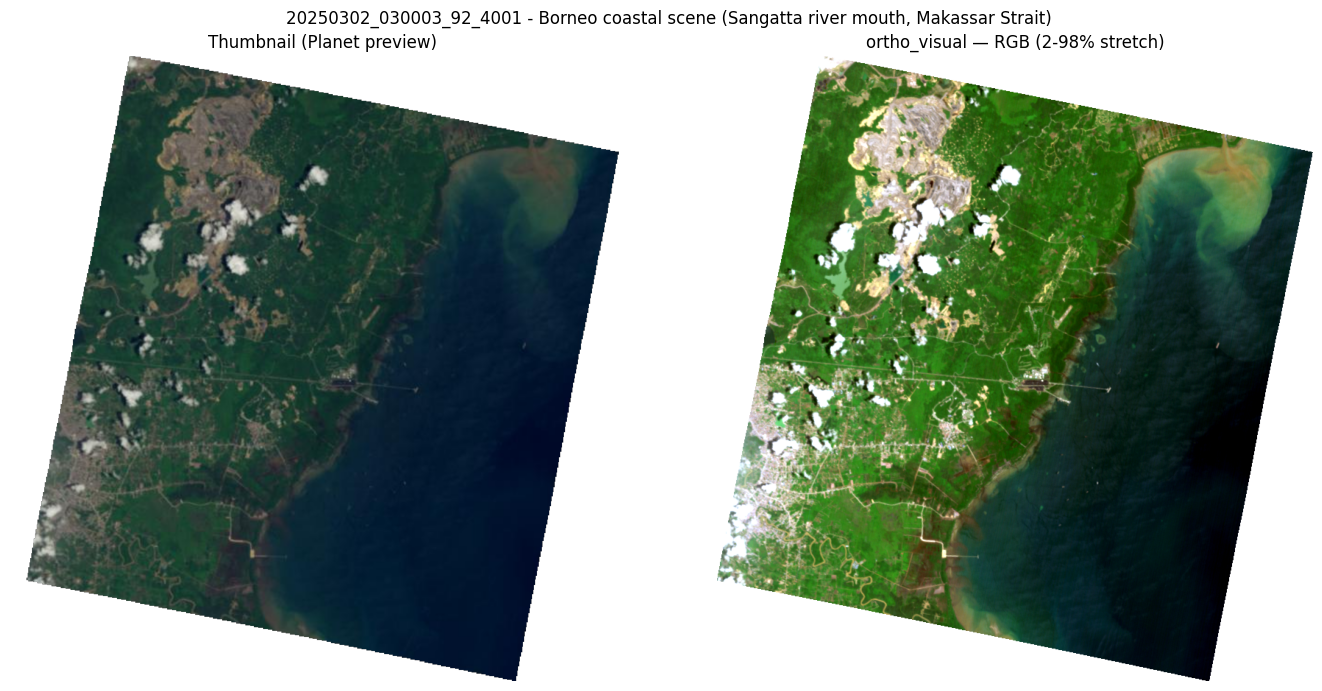

saved -> data/Coastal/figures/01_rgb_overview.png


In [3]:
def stretch(band, lo=2, hi=98, mask=None):
    "Percentile contrast stretch to 0-1, ignoring masked (border) pixels."
    valid = band[mask] if mask is not None else band
    p_lo, p_hi = np.percentile(valid, [lo, hi])
    return np.clip((band - p_lo) / (p_hi - p_lo + 1e-9), 0, 1)

with rasterio.open(DATA_DIR / "ortho_visual.tif") as ds:
    rgb = ds.read([1, 2, 3]).astype("float32")          # (3, H, W) Red, Green, Blue
    alpha = ds.read(4) if ds.count >= 4 else None        # band 4 = alpha (off-swath border)
    bounds = ds.bounds

valid = (alpha > 0) if alpha is not None else np.ones(rgb.shape[1:], bool)
rgb_disp = np.dstack([stretch(rgb[i], mask=valid) for i in range(3)])
if alpha is not None:
    rgb_disp[~valid] = 1.0  # white border instead of black nodata

thumb = Image.open(DATA_DIR / "thumbnail.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(thumb);          axes[0].set_title("Thumbnail (Planet preview)")
axes[1].imshow(rgb_disp);       axes[1].set_title("ortho_visual: RGB (2-98% stretch)")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"{SCENE_ID} - Borneo coastal scene (Sangatta river mouth, Makassar Strait)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_rgb_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved ->", FIG_DIR / "01_rgb_overview.png")


## 3. Quality and cloud mask (`beta_udm`)

`ortho_beta_udm` is Planet's beta **Usable-Data Mask**. It flags cloud, haze, shadow, and off-swath nodata. These pixels can corrupt water-leaving reflectance and create false turbidity or chlorophyll values. Phase 3 uses only pixels that pass this mask.

Band 1 values are `0` for clear or usable, `1` for flagged, and `255` for the nodata border. The left panel draws rejected pixels in red over the RGB image. The right panel shows the raw mask. The printed flagged fraction should be small, about 1% for this 2% cloud scene, and the target plume should remain mostly unflagged.


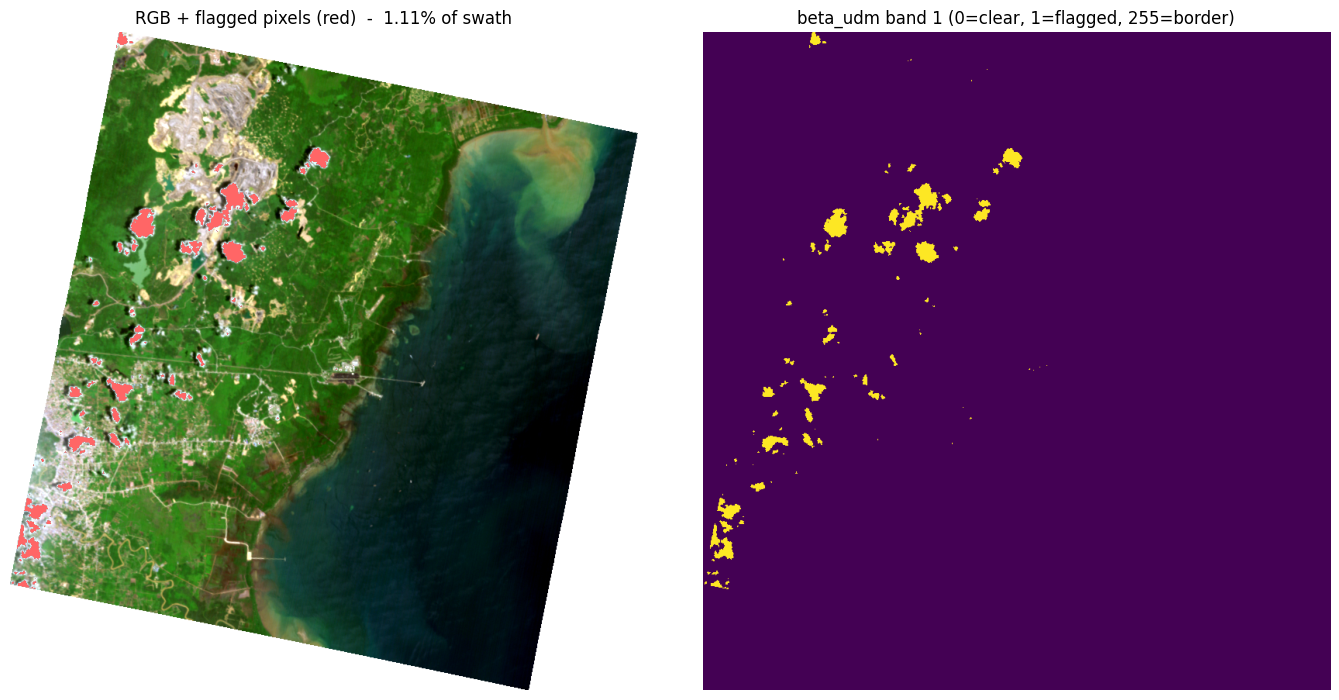

clear=680,851  flagged=7,649  border=0  flagged%=1.11
saved -> data/Coastal/figures/01_udm.png


In [4]:
with rasterio.open(DATA_DIR / "ortho_beta_udm.tif") as ds:
    udm = ds.read(1)            # band 1: 0=clear, 1=flagged, 255=nodata border
    udm_nodata = ds.nodata

flagged = (udm == 1)
clear   = (udm == 0)
border  = (udm == udm_nodata) if udm_nodata is not None else np.zeros_like(udm, bool)
total_in_swath = clear.sum() + flagged.sum()
pct_flagged = 100 * flagged.sum() / max(total_in_swath, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(rgb_disp)
axes[0].imshow(np.ma.masked_where(~flagged, flagged), cmap="autumn", alpha=0.6)
axes[0].set_title(f"RGB + flagged pixels (red)  -  {pct_flagged:.2f}% of swath")
axes[1].imshow(udm, cmap="viridis")
axes[1].set_title("beta_udm band 1 (0=clear, 1=flagged, 255=border)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_udm.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"clear={clear.sum():,}  flagged={flagged.sum():,}  border={border.sum():,}  flagged%={pct_flagged:.2f}")
print("saved ->", FIG_DIR / "01_udm.png")


## Summary and next step

**Phase 1 established**
- The scene is clean, with about 2% cloud, 1% haze, and high sun at 68°.
- A turbid sediment plume leaves the Sangatta river mouth and enters the Makassar Strait. This is a Case-2 coastal-water target.
- The orthorectified RGB image and `beta_udm` mask identify pixels that can be used downstream.

**Parameters for Phases 2 and 3**

| Parameter | Unit | Optical signature | Candidate algorithm |
|---|---|---|---|
| Turbidity / suspended sediment (TSM) | FNU/NTU; g m⁻³ | rising reflectance in red to NIR, about 645 to 750 nm | Nechad single-band; red/NIR ratio |
| Chlorophyll-*a* | mg m⁻³ (≡ µg L⁻¹) | absorption near 443 and 665 nm; red-edge peak near 708 nm | NDCI = (Rrs₇₀₈−Rrs₆₆₅)/(Rrs₇₀₈+Rrs₆₆₅) |
| CDOM | *a*₍g₎(440), m⁻¹ | exponential rise into the blue | green/blue ratio, ρ(560)/ρ(443); *a*₍g₎(λ)=*a*₍g₎(λ₀)·e^(−S(λ−λ₀)) |
| Water mask | – | green high / NIR low over water | NDWI = (Green−NIR)/(Green+NIR) |

**Next:** [`02_spectral_exploration.ipynb`](./02_spectral_exploration.ipynb) checks the water spectra before any retrieval.
